<a href="https://colab.research.google.com/github/sharare-bazdar/Sharare-/blob/main/bert_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
sns.set(style='whitegrid')

In [ ]:
tokenizer=BertTokenizer.from_pretrained('bert-base-uncased')
model=BertModel.from_pretrained('bert-base-uncased', output_attentions=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
text='The cat sat on the mat.'
inputs=tokenizer(text, return_tensors='pt')

In [ ]:
with torch.no_grad():
  outputs=model(**inputs)

attention_weights=outputs.attentions
last_layer_attention=attention_weights[-1].mean(dim=1).squeeze(0)

tokens=tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
token_count=len(tokens)

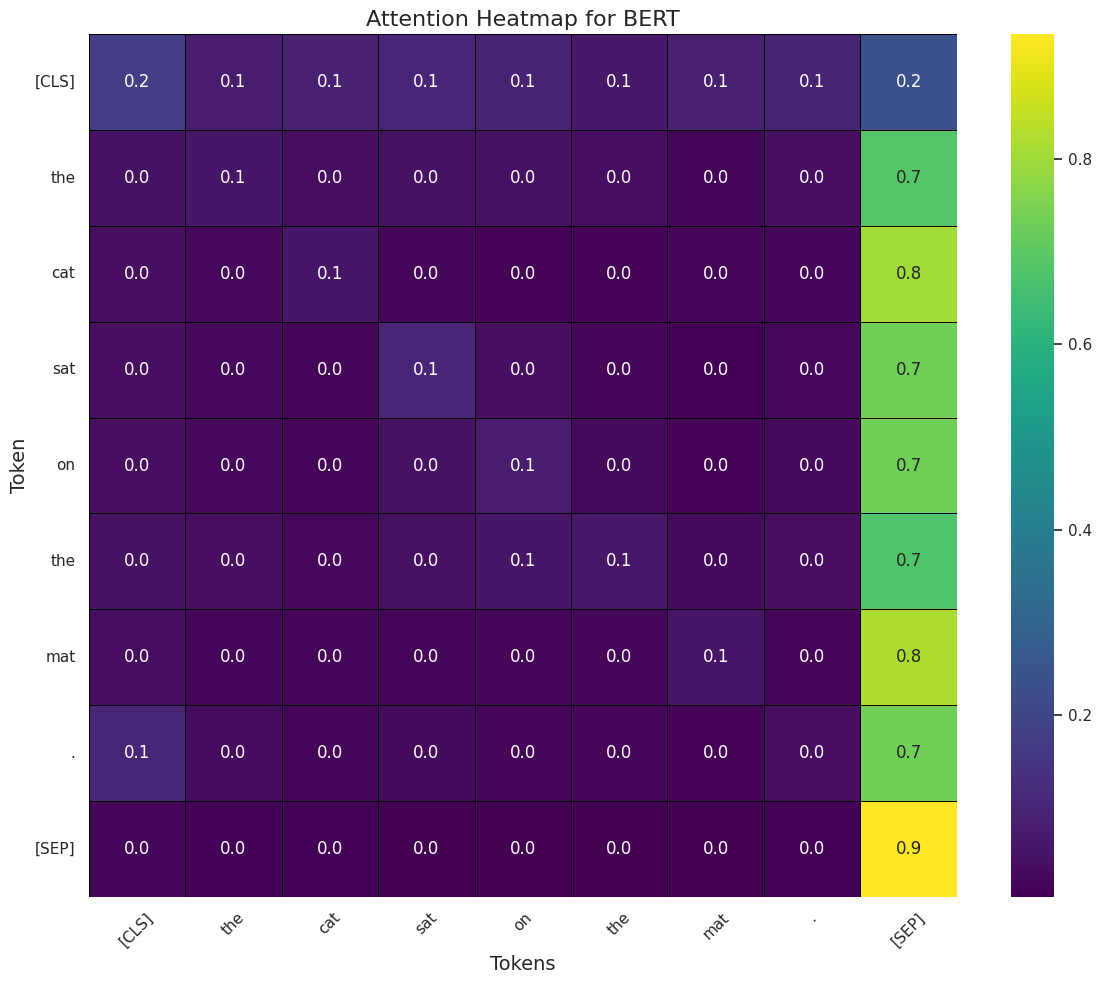

In [ ]:
plt.figure(figsize=(12,10))
heatmap=sns.heatmap(
    last_layer_attention.numpy(),
    xticklabels=tokens,
    yticklabels=tokens,
    cmap='viridis',
    cbar=True,
    annot=True,
    fmt='.1f',
    linewidths=.5,
    linecolor='black'
)

plt.title('Attention Heatmap for BERT', fontsize=16)
plt.xlabel('Tokens',fontsize=14)
plt.ylabel('Token',fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()